In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scripts.memory_reducer import memory_reducer
sys.path.insert(0, os.path.abspath('..'))

# load data
prices = memory_reducer("../data/stock_prices.csv")
sp500 = memory_reducer("../data/sp500.csv")


prices = prices.set_index("Date")
prices = prices.resample("ME").last()
prices = prices.sort_index()

print(prices.shape)
prices.head(3)

(169, 543)


,A,AA,AAPL,ABBV,ABC,ABT,ACE,ACI,ACN,ACT,...,XOM,XRAY,XRX,XYL,YHOO,YUM,ZION,ZLC,ZMH,ZNGA
Date,,,,,,,,,,,,,,,,,,,,,
2000-12-31,36.730354,25.950483,1.006463,NaN,11.438262,38.794544,31.431623,6.057003,NaN,51.189999,...,31.512054,12.280495,3.956393,NaN,15.030000,6.963493,51.146896,14.53,NaN,NaN
2001-01-31,36.596180,28.576517,1.462347,NaN,10.833507,35.999401,27.402687,6.177114,NaN,52.060001,...,30.500799,10.846253,6.996479,NaN,18.655001,7.600759,45.773357,18.65,NaN,NaN
2001-02-28,24.151464,27.814268,1.234405,NaN,12.167593,39.313656,27.106441,10.102155,NaN,55.500000,...,29.453793,11.809737,5.215245,NaN,11.905000,8.124076,47.212597,15.73,NaN,NaN


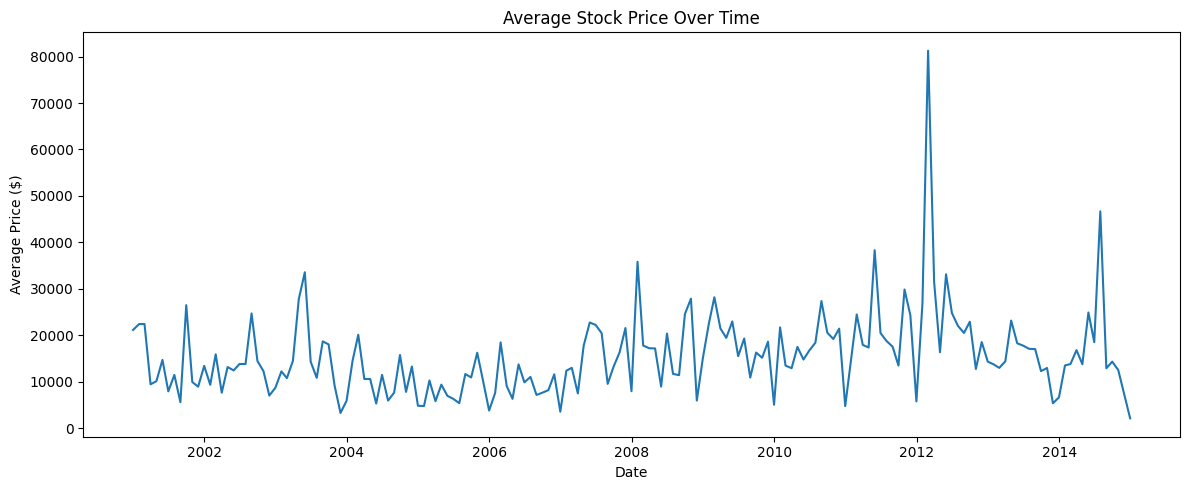

In [89]:
def plot_avg_price(prices, plot=False):
    os.makedirs("../results/plots", exist_ok=True)

    avg_price = prices.mean(axis=1)  # mean across all companies per month
    
    plt.figure(figsize=(12, 5))
    plt.plot(avg_price.index, avg_price.values)
    plt.title("Average Stock Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average Price ($)")
    plt.tight_layout()
    plt.savefig("../results/plots/avg_price.png")
    
    if plot:
        plt.show()
    plt.close()

plot_avg_price(prices, plot=True)

In [ ]:
def plot_missing_values(prices, plot=False):
    os.makedirs("../results/plots", exist_ok=True)

    missing_per_month = prices.isnull().sum(axis=1)
    missing_per_year = missing_per_month.resample('YE').sum()

    fig, ax = plt.subplots(figsize=(14, 6))

    bars = ax.bar(
        missing_per_year.index.year,
        missing_per_year.values,
        color='salmon',
        linewidth=0.5
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8,
        )

    ax.set_title("Number of Missing Values per Year", fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Missing Values Count", fontsize=12)

    plt.tight_layout()
    fig.savefig("../results/plots/missing_values.png", bbox_inches='tight')
    plt.close(fig)

    if plot:
        plt.show()
    plt.close()

plot_missing_values(prices)

In [91]:
# .stack() transforme les colonnes en lignes
prices_long = prices.stack().to_frame('Price')

prices_long.index.names = ['Date', 'Ticker']

# On trie pour que les dates d'une meme entreprise se suivent
prices_long = prices_long.sort_index(level=['Ticker', 'Date'])

# Find price outliers
outliers_df = prices_long[(prices_long['Price'] > 5000) | (prices_long['Price'] < 0.5)]
outliers_df = outliers_df.sort_values('Price', ascending=False)
print(f"Number of suspicious prices: {len(outliers_df)}")
outliers_df.head(20)

print("Nouveau format (Long) :")
print(prices_long.head(10))


Number of suspicious prices: 1592
Nouveau format (Long) :
                       Price
Date       Ticker           
2000-12-31 A       36.730354
2001-01-31 A       36.596180
2001-02-28 A       24.151464
2001-03-31 A       20.615959
2001-04-30 A       26.170795
2001-05-31 A       22.501116
2001-06-30 A       21.803406
2001-07-31 A       19.193707
2001-08-31 A       17.778162
2001-09-30 A       13.115587


In [95]:
# Top 3 highest prices
top_high = outliers_df.sort_values('Price', ascending=False).head(3)

# Top 2 lowest non-zero prices
top_low = outliers_df[outliers_df['Price'] > 0].sort_values('Price').head(2)

# Combine
selected_outliers = pd.concat([top_high, top_low])

os.makedirs("../results", exist_ok=True)

with open("../results/outliers.txt", "w") as f:
    f.write("Identified Price Outliers\n")
    f.write("=" * 50 + "\n\n")
    
    for i, (idx, row) in enumerate(selected_outliers.iterrows(), 1):
        date, ticker = idx  # unpack multi-index
        f.write(f"{i}. Ticker    : {ticker}\n")
        f.write(f"   Date      : {date.date()}\n")
        f.write(f"   Price     : ${row['Price']:.2f}\n")
        f.write(f"   Note      : Abnormal price detected\n")
        f.write("-" * 50 + "\n\n")

print("outliers.txt saved")
print(selected_outliers)

outliers.txt saved
                          Price
Date       Ticker              
2012-02-29 SPLS    4.352770e+07
2014-07-31 SPLS    2.498781e+07
2011-05-31 SPLS    2.021030e+07
2014-10-31 EMC     1.135052e-43
           KIM     1.886989e-41


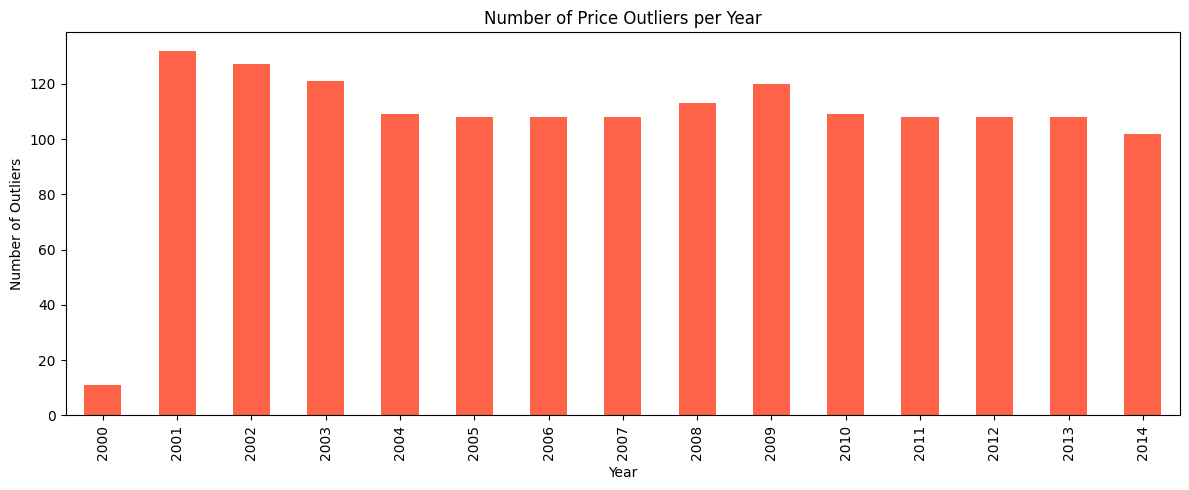

In [93]:
def plot_outliers(prices_long, plot=False):
    os.makedirs("../results/plots", exist_ok=True)
    
    outliers = prices_long[(prices_long['Price'] > 5000) | (prices_long['Price'] < 0.5)]
    outliers_per_year = outliers.groupby(
        outliers.index.get_level_values('Date').year
    )['Price'].count()

    plt.figure(figsize=(12, 5))
    outliers_per_year.plot(kind='bar', color='tomato')
    plt.title("Number of Price Outliers per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Outliers")
    plt.tight_layout()
    plt.savefig("../results/plots/outliers.png")
    
    if plot:
        plt.show()
    plt.close()

plot_outliers(prices_long, plot=True)